In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.corpus import stopwords
import string
import urllib.request
import zipfile
import os

# Download NLTK data if not already present
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True) # Needs punkt_tab for standard nltk tokenization

True

In [4]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
zip_path = "smsspamcollection.zip"

if not os.path.exists('SMSSpamCollection'):
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")
    os.remove(zip_path)

In [5]:
df = pd.read_csv('SMSSpamCollection', sep='\t', names=['label', 'message'])
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
label      0
message    0
dtype: int64


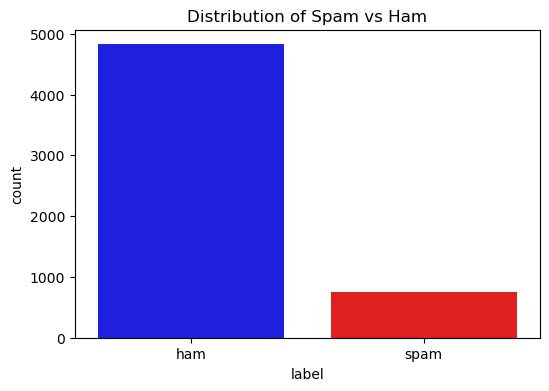

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', hue='label', legend=False, palette={'ham': 'blue', 'spam': 'red'})
plt.title('Distribution of Spam vs Ham')
plt.show()

In [8]:
df['message_length'] = df['message'].apply(len)
df.groupby('label')['message_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.482487,58.440652,2.0,33.0,52.0,93.0,910.0
spam,747.0,138.670683,28.873603,13.0,133.0,149.0,157.0,223.0


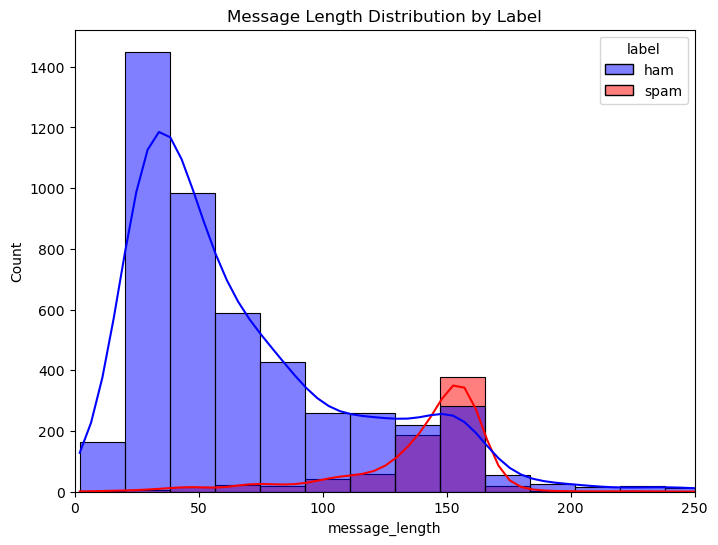

In [9]:
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='message_length', hue='label', bins=50, kde=True, palette={'ham': 'blue', 'spam': 'red'})
plt.title('Message Length Distribution by Label')
plt.xlim(0, 250)
plt.show()

## Text Preprocessing
Before extracting word-level features, we must clean the text data:
1. **Lowercasing**
2. **Punctuation removal**
3. **Tokenization** (Splitting strings to words)
4. **Stop-word removal** (Removing fillers like 'and', 'the')

In [10]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = "".join([char for char in text if char not in string.punctuation])
    # Tokenize and remove stopwords
    tokens = nltk.word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return filtered_tokens

print("Preprocessing Text (This might take a moment)...")
df['clean_tokens'] = df['message'].apply(clean_text)
df[['message', 'clean_tokens']].head()

Preprocessing Text (This might take a moment)...


,message,clean_tokens
0,"Go until jurong point, crazy.. Available only ...","[go, jurong, point, crazy, available, bugis, n..."
1,Ok lar... Joking wif u oni...,"[ok, lar, joking, wif, u, oni]"
2,Free entry in 2 a wkly comp to win FA Cup fina...,"[free, entry, 2, wkly, comp, win, fa, cup, fin..."
3,U dun say so early hor... U c already then say...,"[u, dun, say, early, hor, u, c, already, say]"
4,"Nah I don't think he goes to usf, he lives aro...","[nah, dont, think, goes, usf, lives, around, t..."


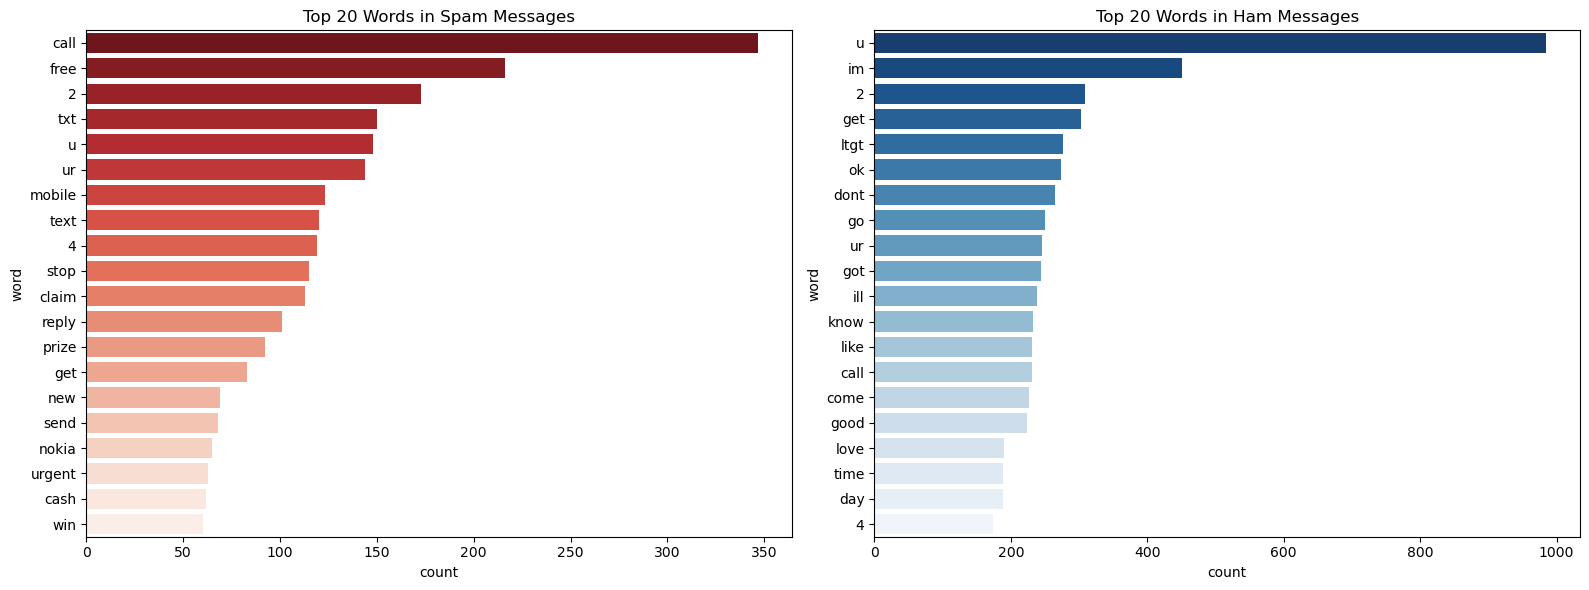

In [11]:
# Separate spam and ham tokens
spam_words = []
for tokens in df[df['label'] == 'spam']['clean_tokens']:
    spam_words.extend(tokens)
    
ham_words = []
for tokens in df[df['label'] == 'ham']['clean_tokens']:
    ham_words.extend(tokens)

# Get top 20 most common words
spam_top20 = Counter(spam_words).most_common(20)
ham_top20 = Counter(ham_words).most_common(20)

spam_df = pd.DataFrame(spam_top20, columns=['word', 'count'])
ham_df = pd.DataFrame(ham_top20, columns=['word', 'count'])

# Plot most common words
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=spam_df, x='count', y='word', ax=axes[0], hue='word', palette='Reds_r', legend=False)
axes[0].set_title('Top 20 Words in Spam Messages')

sns.barplot(data=ham_df, x='count', y='word', ax=axes[1], hue='word', palette='Blues_r', legend=False)
axes[1].set_title('Top 20 Words in Ham Messages')

plt.tight_layout()
plt.show()